<a href="https://colab.research.google.com/github/harshitnagar22/Celebal_CEI/blob/main/Week5_Harshit_Nagar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

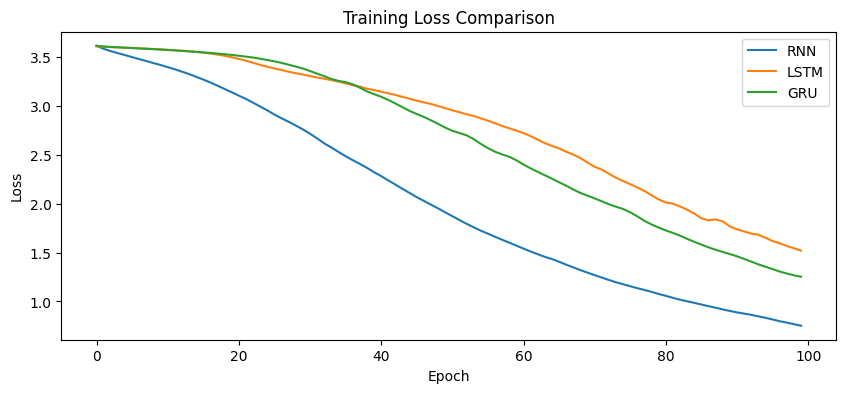

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [10]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning models meaningful meaningful sentences
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [11]:
# Task 1: Custom corpus replacing the boilerplate text
custom_corpus = '''
artificial intelligence is changing the way we live and work
machine learning models learn patterns from large amounts of data
neural networks are inspired by the structure of the human brain
deep learning has enabled breakthroughs in vision and language understanding
natural language processing helps computers understand human text
this project explores how sequence models generate meaningful sentences
'''
print(custom_corpus)

# Re-tokenize on the new corpus
tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([custom_corpus])

total_words2 = len(tokenizer2.word_index) + 1
print("New vocabulary size:", total_words2)

input_sequences2 = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences2.append(n_gram_seq)

max_len2 = max(len(seq) for seq in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)


artificial intelligence is changing the way we live and work
machine learning models learn patterns from large amounts of data
neural networks are inspired by the structure of the human brain
deep learning has enabled breakthroughs in vision and language understanding
natural language processing helps computers understand human text
this project explores how sequence models generate meaningful sentences

New vocabulary size: 51
X2 shape: (52, 10)
y2 shape: (52,)


In [12]:
# Task 2: Bigger embedding dimension (32 -> 100) on the new corpus
lstm_big_embed = Sequential([
    Embedding(total_words2, 100, input_length=max_len2-1),
    LSTM(64),
    Dense(total_words2, activation='softmax')
])

lstm_big_embed.compile(loss='sparse_categorical_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])

lstm_big_embed_history = lstm_big_embed.fit(X2, y2, epochs=100, verbose=0)
print("LSTM with embedding_dim=100 training completed")

LSTM with embedding_dim=100 training completed


GRU (200 epochs) training completed


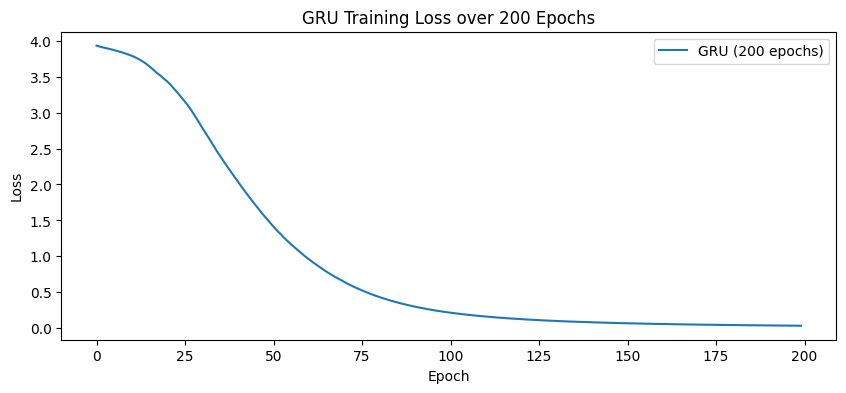

In [13]:
# Task 3: Train for 200 epochs instead of 100
gru_200ep = Sequential([
    Embedding(total_words2, 100, input_length=max_len2-1),
    GRU(64),
    Dense(total_words2, activation='softmax')
])

gru_200ep.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_200ep_history = gru_200ep.fit(X2, y2, epochs=200, verbose=0)
print("GRU (200 epochs) training completed")

# Quick loss curve to confirm convergence
plt.figure(figsize=(10,4))
plt.plot(gru_200ep_history.history['loss'], label='GRU (200 epochs)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training Loss over 200 Epochs")
plt.legend()
plt.show()

Wide RNN (128 units) training completed
Wide LSTM (128 units) training completed
Wide GRU (128 units) training completed


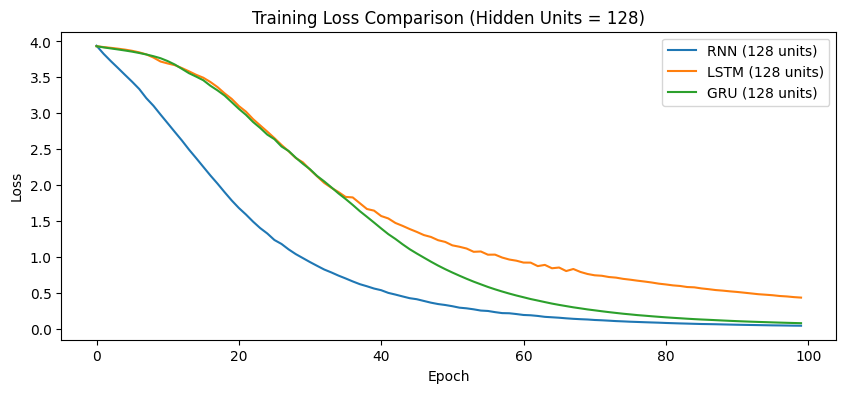

In [14]:
# Task 4: Hidden units increased from 64 to 128, across all three architectures
rnn_wide = Sequential([
    Embedding(total_words2, 100, input_length=max_len2-1),
    SimpleRNN(128),
    Dense(total_words2, activation='softmax')
])
rnn_wide.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_wide_history = rnn_wide.fit(X2, y2, epochs=100, verbose=0)
print("Wide RNN (128 units) training completed")

lstm_wide = Sequential([
    Embedding(total_words2, 100, input_length=max_len2-1),
    LSTM(128),
    Dense(total_words2, activation='softmax')
])
lstm_wide.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_wide_history = lstm_wide.fit(X2, y2, epochs=100, verbose=0)
print("Wide LSTM (128 units) training completed")

gru_wide = Sequential([
    Embedding(total_words2, 100, input_length=max_len2-1),
    GRU(128),
    Dense(total_words2, activation='softmax')
])
gru_wide.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_wide_history = gru_wide.fit(X2, y2, epochs=100, verbose=0)
print("Wide GRU (128 units) training completed")

# Compare loss curves of all three widened models
plt.figure(figsize=(10,4))
plt.plot(rnn_wide_history.history['loss'], label='RNN (128 units)')
plt.plot(lstm_wide_history.history['loss'], label='LSTM (128 units)')
plt.plot(gru_wide_history.history['loss'], label='GRU (128 units)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (Hidden Units = 128)")
plt.legend()
plt.show()

In [15]:
# Task 5: Generate 10 words per model using the new tokenizer/max_len
def generate_text_v2(model, seed_text, tokenizer_obj, max_len_val, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer_obj.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len_val-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer_obj.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

print("RNN  (10 words):", generate_text_v2(rnn_wide, "artificial intelligence", tokenizer2, max_len2, 10))
print("LSTM (10 words):", generate_text_v2(lstm_wide, "artificial intelligence", tokenizer2, max_len2, 10))
print("GRU  (10 words):", generate_text_v2(gru_wide, "artificial intelligence", tokenizer2, max_len2, 10))

RNN  (10 words): artificial intelligence is changing the way we live and work helps and
LSTM (10 words): artificial intelligence is changing the way we live and work work work
GRU  (10 words): artificial intelligence is changing the way we live and work work work


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**